Observations are filtered to science periods from notebook 00.

# Validation plots: trajectory comparison and skill scores

Reads simulation output (zarr) from notebook 04 and observed drifter
tracks, then produces trajectory maps, separation distance curves, and
summary skill metrics for three simulation types:

- **Drogued drifter (DD)** — steady-state tilt + effective currents
- **Surface point particle** — z = 0, effective currents
- **3 m point particle** — z = 3 m, effective currents

## Parameters

In [1]:
ZARR_DD = "output/sim_drogued_drifter.zarr"
ZARR_SURFACE = "output/sim_surface.zarr"
ZARR_3M = "output/sim_3m.zarr"
CSV_SCIENCE = "data/drifters_science.csv"

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

## Load data

In [3]:
# Science-period observations at 1-min resolution from notebook 00
obs_df = pd.read_csv(CSV_SCIENCE, parse_dates=["date_UTC"])

drifter_ids = sorted(obs_df["D_number"].unique())
print("Drifter IDs:", drifter_ids)
print("Obs date range:", obs_df["date_UTC"].min(), "to", obs_df["date_UTC"].max())
print(f"Science observations: {len(obs_df)}")

Drifter IDs: ['D298', 'D299', 'D300', 'D301', 'D302', 'D303']
Obs date range: 2023-04-24 08:00:00 to 2023-05-06 17:59:00
Science observations: 80940


In [4]:
ds_dd = xr.open_zarr(ZARR_DD).load()
ds_surface = xr.open_zarr(ZARR_SURFACE).load()
ds_3m = xr.open_zarr(ZARR_3M).load()

# Trajectory index i maps to drifter_ids[i] (same sorted order as in notebook 04)
print("DD dims:", dict(ds_dd.sizes))
print("Surface dims:", dict(ds_surface.sizes))
print("3m dims:", dict(ds_3m.sizes))

DD dims: {'trajectory': 6, 'obs': 289}
Surface dims: {'trajectory': 6, 'obs': 289}
3m dims: {'trajectory': 6, 'obs': 289}


In [5]:
def ds_to_dicts(ds, drifter_ids):
    """Convert zarr dataset to dict keyed by drifter ID.

    Trajectory index i corresponds to drifter_ids[i].
    NaN positions (deleted particles) are dropped.
    """
    out = {}
    for i, did in enumerate(drifter_ids):
        lon = ds.lon.isel(trajectory=i).values
        lat = ds.lat.isel(trajectory=i).values
        time = ds.time.isel(trajectory=i).values
        valid = np.isfinite(lon) & np.isfinite(lat)
        out[did] = {"lon": lon[valid], "lat": lat[valid], "time": time[valid]}
    return out


sim_dd = ds_to_dicts(ds_dd, drifter_ids)
sim_surface = ds_to_dicts(ds_surface, drifter_ids)
sim_3m = ds_to_dicts(ds_3m, drifter_ids)

for did in drifter_ids:
    print(f"{did}: DD {len(sim_dd[did]['lon'])} pts, "
          f"surface {len(sim_surface[did]['lon'])} pts, "
          f"3m {len(sim_3m[did]['lon'])} pts")

D298: DD 289 pts, surface 289 pts, 3m 289 pts
D299: DD 289 pts, surface 289 pts, 3m 289 pts
D300: DD 289 pts, surface 289 pts, 3m 289 pts
D301: DD 289 pts, surface 289 pts, 3m 289 pts
D302: DD 289 pts, surface 289 pts, 3m 289 pts
D303: DD 289 pts, surface 289 pts, 3m 289 pts


## Helper functions

In [6]:
def haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance in km."""
    R = 6371.0
    dlat = np.deg2rad(lat2 - lat1)
    dlon = np.deg2rad(lon2 - lon1)
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(np.deg2rad(lat1)) * np.cos(np.deg2rad(lat2)) * np.sin(dlon / 2) ** 2
    )
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def interp_sim_to_obs(sim_time, sim_lon, sim_lat, obs_time):
    """Linearly interpolate simulated lon/lat to observed timestamps."""
    sim_t = sim_time.astype(np.float64)
    obs_t = obs_time.astype(np.float64)
    lon_i = np.interp(obs_t, sim_t, sim_lon)
    lat_i = np.interp(obs_t, sim_t, sim_lat)
    return lon_i, lat_i

## Trajectory map

Observed tracks and all three simulation types plotted on an OSM tile
background. One panel per drifter. Use `ccrs.Geodetic()` as transform
for OSM tiles to avoid the ~43 km offset that PlateCarree produces.

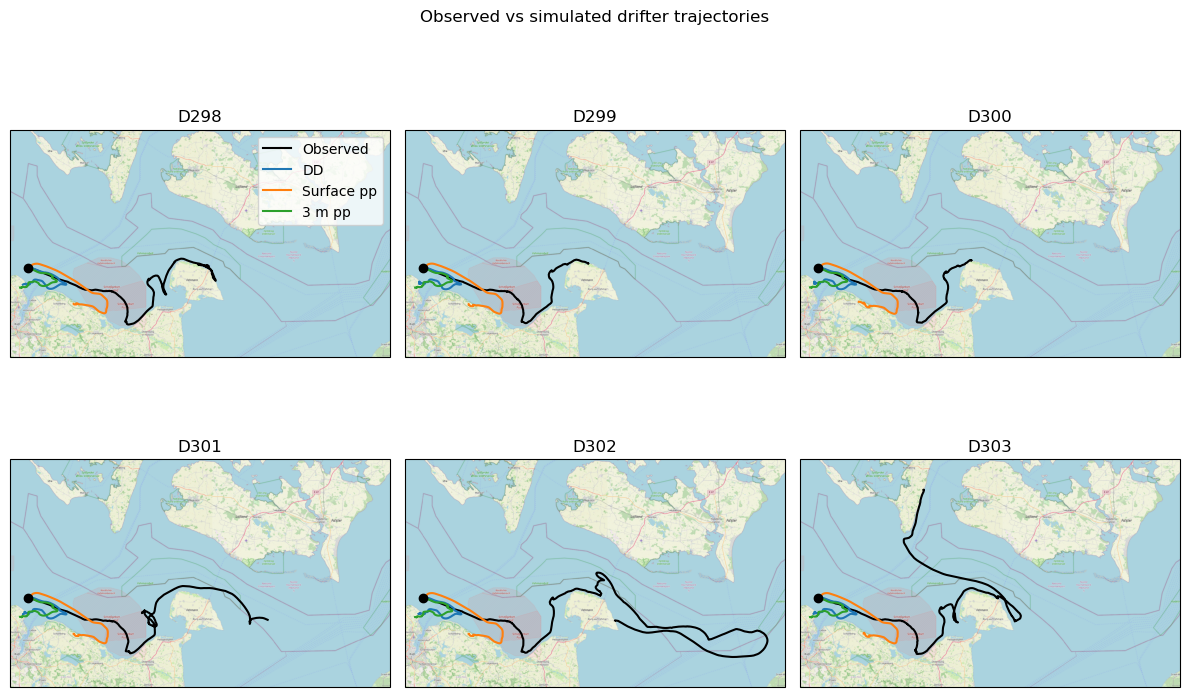

In [7]:
# Derive bounding box from science-period observations with ~0.1 deg padding
PAD = 0.1
lon_min = obs_df["Longitude"].min() - PAD
lon_max = obs_df["Longitude"].max() + PAD
lat_min = obs_df["Latitude"].min() - PAD
lat_max = obs_df["Latitude"].max() + PAD

osm = cimgt.OSM()
geodetic = ccrs.Geodetic()

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8),
    subplot_kw={"projection": osm.crs},
)

for ax, did in zip(axes.flat, drifter_ids):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=geodetic)
    ax.add_image(osm, 10)

    obs = obs_df[obs_df["D_number"] == did]
    ax.plot(obs["Longitude"].values, obs["Latitude"].values,
            color="black", transform=geodetic, label="Observed")

    for label, sim_dict, color in [
        ("DD", sim_dd, "tab:blue"),
        ("Surface pp", sim_surface, "tab:orange"),
        ("3 m pp", sim_3m, "tab:green"),
    ]:
        s = sim_dict[did]
        if len(s["lon"]) < 2:
            continue
        ax.plot(s["lon"], s["lat"], color=color,
                transform=geodetic, label=label)

    ax.plot(obs["Longitude"].iloc[0], obs["Latitude"].iloc[0],
            "ko", transform=geodetic)

    ax.set_title(did)

axes.flat[0].legend(loc=0)
fig.suptitle("Observed vs simulated drifter trajectories")
plt.tight_layout()
plt.show()

## Separation distance

Great-circle (haversine) distance between observed and simulated
positions as a function of time since simulation start. Simulated
positions are interpolated to observed timestamps.

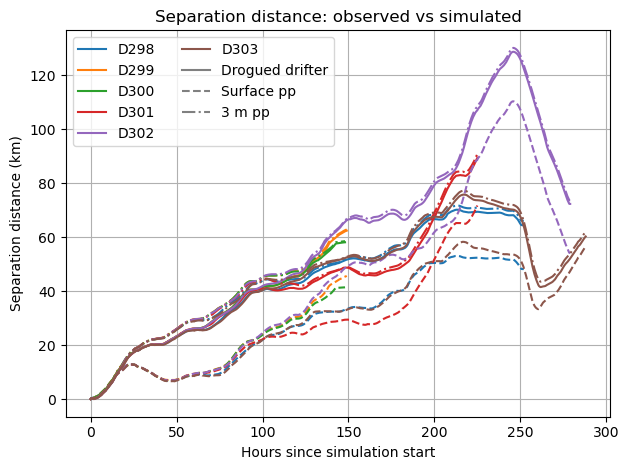

In [8]:
tab_colors = plt.cm.tab10(range(len(drifter_ids)))

fig, ax = plt.subplots()

for i, did in enumerate(drifter_ids):
    obs = obs_df[obs_df["D_number"] == did]
    obs_time = obs["date_UTC"].values.astype("datetime64[ns]")
    obs_lon = obs["Longitude"].values
    obs_lat = obs["Latitude"].values
    t0 = obs_time[0]

    for key, sim_dict, ls in [
        ("dd", sim_dd, "-"),
        ("surface", sim_surface, "--"),
        ("3m", sim_3m, "-."),
    ]:
        s = sim_dict[did]
        if len(s["lon"]) < 2:
            continue
        sim_end = s["time"][-1]
        obs_mask = (obs_time >= s["time"][0]) & (obs_time <= sim_end)
        if obs_mask.sum() < 2:
            continue
        ot = obs_time[obs_mask]
        hours = (ot - t0).astype(np.float64) / 3.6e12
        sim_lon_i, sim_lat_i = interp_sim_to_obs(
            s["time"], s["lon"], s["lat"], ot,
        )
        sep = haversine_km(sim_lon_i, sim_lat_i, obs_lon[obs_mask], obs_lat[obs_mask])
        label = did if ls == "-" else None
        ax.plot(hours, sep, color=tab_colors[i], ls=ls, label=label)

# Line-style legend entries
ax.plot([], [], color="gray", ls="-", label="Drogued drifter")
ax.plot([], [], color="gray", ls="--", label="Surface pp")
ax.plot([], [], color="gray", ls="-.", label="3 m pp")

ax.set_xlabel("Hours since simulation start")
ax.set_ylabel("Separation distance (km)")
ax.set_title("Separation distance: observed vs simulated")
ax.grid()
ax.legend(loc=0, ncol=2)
plt.tight_layout()
plt.show()

## Summary statistics

Mean and maximum separation distance per drifter per simulation type,
computed over the full overlapping time window.

In [9]:
rows = []

for did in drifter_ids:
    obs = obs_df[obs_df["D_number"] == did]
    obs_time = obs["date_UTC"].values.astype("datetime64[ns]")
    obs_lon = obs["Longitude"].values
    obs_lat = obs["Latitude"].values

    for sim_name, sim_dict in [
        ("Drogued drifter", sim_dd),
        ("Surface pp", sim_surface),
        ("3 m pp", sim_3m),
    ]:
        s = sim_dict[did]
        if len(s["lon"]) < 2:
            rows.append({"Drifter": did, "Simulation": sim_name,
                         "Mean sep (km)": np.nan, "Max sep (km)": np.nan,
                         "Duration (h)": 0.0})
            continue

        obs_mask = (obs_time >= s["time"][0]) & (obs_time <= s["time"][-1])
        if obs_mask.sum() < 2:
            rows.append({"Drifter": did, "Simulation": sim_name,
                         "Mean sep (km)": np.nan, "Max sep (km)": np.nan,
                         "Duration (h)": 0.0})
            continue

        ot = obs_time[obs_mask]
        sim_lon_i, sim_lat_i = interp_sim_to_obs(
            s["time"], s["lon"], s["lat"], ot,
        )
        sep = haversine_km(sim_lon_i, sim_lat_i, obs_lon[obs_mask], obs_lat[obs_mask])
        duration_h = float((ot[-1] - ot[0])) / 3.6e12

        rows.append({
            "Drifter": did,
            "Simulation": sim_name,
            "Mean sep (km)": float(np.mean(sep)),
            "Max sep (km)": float(np.max(sep)),
            "Duration (h)": duration_h,
        })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False, float_format="{:.3f}".format))
print()
print("--- Mean across all drifters by simulation type ---")
summary = result_df.groupby("Simulation")[["Mean sep (km)", "Max sep (km)"]].mean()
print(summary.to_string(float_format="{:.3f}".format))

Drifter      Simulation  Mean sep (km)  Max sep (km)  Duration (h)
   D298 Drogued drifter         43.154        70.256       251.983
   D298      Surface pp         28.369        53.126       251.983
   D298          3 m pp         44.910        71.801       251.983
   D299 Drogued drifter         31.749        62.457       148.983
   D299      Surface pp         18.571        45.690       148.983
   D299          3 m pp         33.763        62.913       148.983
   D300 Drogued drifter         31.204        58.171       147.983
   D300      Surface pp         17.924        41.512       147.983
   D300          3 m pp         33.223        58.595       147.983
   D301 Drogued drifter         39.871        89.499       224.983
   D301      Surface pp         24.975        71.787       224.983
   D301          3 m pp         41.532        90.909       224.983
   D302 Drogued drifter         58.675       128.791       278.983
   D302      Surface pp         43.575       110.415       278